# **Imports**

In [1]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# **Mount Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Paths**

In [3]:
BASE_DIR = "/content/drive/MyDrive/AI-TeleTriage-System"

SAVE_DIR = os.path.join(BASE_DIR, "saved_objects")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# **Load Existing DataFrames**

In [4]:
with open(os.path.join(SAVE_DIR, "train_df.pkl"), "rb") as f:
    train_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "val_df.pkl"), "rb") as f:
    val_df = pickle.load(f)

with open(os.path.join(SAVE_DIR, "test_df.pkl"), "rb") as f:
    test_df = pickle.load(f)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 11)
(1502, 11)
(1503, 11)


# **Check Columns**

In [5]:
print(train_df.columns)
train_df.head()

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'path', 'disease', 'label', 'symptoms'],
      dtype='object')


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,disease,label,symptoms
4357,HAM_0000946,ISIC_0031775,nv,follow_up,60.0,male,trunk,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5,Patient age 60 years. Sex male. Occupation Far...
1751,HAM_0006097,ISIC_0027306,mel,histo,60.0,male,chest,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanoma,4,Patient age 60 years. Sex male. Occupation Sho...
9527,HAM_0004348,ISIC_0033895,nv,consensus,40.0,female,unknown,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5,Patient age 40 years. Sex female. Occupation D...
8311,HAM_0006608,ISIC_0025491,nv,histo,60.0,male,back,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanocytic Nevi,5,Patient age 60 years. Sex male. Occupation Off...
1214,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,/content/drive/MyDrive/AI-TeleTriage-System/da...,Melanoma,4,Patient age 60 years. Sex male. Occupation Eng...


# **Clinical Dictionaries**

In [6]:
import random

occupations = [
    "Teacher","Engineer","Farmer","Driver","Office Worker","Student",
    "Shopkeeper","Businessman","Nurse","Doctor","Mechanic",
    "Electrician","Painter","Retired","Police Officer","Tailor"
]

durations = [
    "2 weeks","1 month","2 months","3 months",
    "6 months","1 year","18 months"
]

complaints = [
    "noticed a skin lesion",
    "observed a pigmented mole",
    "reports a dark patch",
    "noticed a small bump",
    "developed a skin growth",
    "noticed discoloration of skin",
    "observed a raised lesion"
]

common_symptoms = [
    "mild itching",
    "occasional irritation",
    "slight tenderness",
    "no pain",
    "slow enlargement",
    "dry surface",
    "rough texture",
    "mild redness",
    "no bleeding",
    "occasional crusting"
]

risk_factors = [
    "frequent sunlight exposure",
    "family history of skin disease",
    "history of outdoor work",
    "fair complexion",
    "no previous skin disease",
    "previous skin lesion removal",
    "uses sunscreen occasionally",
    "chronic sun exposure"
]

# **Disease-specific findings**

In [7]:
disease_features = {

    "mel":[
        "irregular pigmentation",
        "variation in colour",
        "asymmetrical appearance",
        "recent increase in size",
        "uneven border"
    ],

    "nv":[
        "uniform pigmentation",
        "well-defined border",
        "stable appearance",
        "round lesion",
        "smooth surface"
    ],

    "bcc":[
        "pearly surface",
        "rolled edge",
        "small ulceration",
        "slow growth",
        "shiny appearance"
    ],

    "akiec":[
        "rough scaly surface",
        "persistent crust",
        "thickened skin",
        "erythematous plaque",
        "sun exposed area"
    ],

    "bkl":[
        "waxy appearance",
        "rough texture",
        "slightly raised lesion",
        "brown pigmentation",
        "well circumscribed"
    ],

    "df":[
        "firm skin nodule",
        "small round lesion",
        "slow progression",
        "well localized",
        "slightly elevated"
    ],

    "vasc":[
        "reddish coloration",
        "vascular appearance",
        "soft texture",
        "compressible lesion",
        "small superficial lesion"
    ]

}

# **Generate Better Clinical Notes**

In [8]:
def generate_note(row):

    age = int(row.age)

    sex = row.sex

    location = row.localization

    dx = row.dx

    occ = random.choice(occupations)

    duration = random.choice(durations)

    complaint = random.choice(complaints)

    feature1 = random.choice(disease_features[dx])

    feature2 = random.choice(disease_features[dx])

    symptom = random.choice(common_symptoms)

    risk = random.choice(risk_factors)

    note = f"""
Patient is a {age}-year-old {sex} working as a {occ}.
Presented with {complaint} over the {location}.
Lesion has been present for approximately {duration}.
Clinical examination revealed {feature1} with {feature2}.
Patient reports {symptom}.
Past history includes {risk}.
General condition otherwise stable.
"""

    return " ".join(note.split())

# **Create Symptoms Column**

In [9]:
train_df["symptoms"] = train_df.apply(generate_note, axis=1)

val_df["symptoms"] = val_df.apply(generate_note, axis=1)

test_df["symptoms"] = test_df.apply(generate_note, axis=1)

In [10]:
train_df[["dx","symptoms"]].head(10)

,dx,symptoms
4357,nv,Patient is a 60-year-old male working as a Off...
1751,mel,Patient is a 60-year-old male working as a Tea...
9527,nv,Patient is a 40-year-old female working as a S...
8311,nv,Patient is a 60-year-old male working as a Stu...
1214,mel,Patient is a 60-year-old male working as a Sho...
3606,nv,Patient is a 45-year-old male working as a Pai...
1129,df,Patient is a 35-year-old female working as a D...
481,bkl,Patient is a 55-year-old female working as a M...
2294,mel,Patient is a 50-year-old male working as a Ret...
4593,nv,Patient is a 45-year-old male working as a Pol...


In [11]:
train_df[["dx","symptoms"]].head(10)

,dx,symptoms
4357,nv,Patient is a 60-year-old male working as a Off...
1751,mel,Patient is a 60-year-old male working as a Tea...
9527,nv,Patient is a 40-year-old female working as a S...
8311,nv,Patient is a 60-year-old male working as a Stu...
1214,mel,Patient is a 60-year-old male working as a Sho...
3606,nv,Patient is a 45-year-old male working as a Pai...
1129,df,Patient is a 35-year-old female working as a D...
481,bkl,Patient is a 55-year-old female working as a M...
2294,mel,Patient is a 50-year-old male working as a Ret...
4593,nv,Patient is a 45-year-old male working as a Pol...


# **Tokenization & BiLSTM**

# **Prepare Text**

In [14]:
X_train = train_df["symptoms"].astype(str)
X_val   = val_df["symptoms"].astype(str)
X_test  = test_df["symptoms"].astype(str)

y_train = train_df["label"]
y_val   = val_df["label"]
y_test  = test_df["label"]

# **Tokenizer**

In [15]:
MAX_WORDS = 12000
MAX_LEN = 60

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

# **Convert to Sequences**

In [16]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# **Padding**

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)

(7010, 60)


# **One-Hot Labels**

In [18]:
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 7

y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

# **Save Tokenizer**

In [19]:
import pickle
import os

with open(os.path.join(SAVE_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

# **Build BiLSTM**

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

EMBEDDING_DIM = 128

model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.3,
            recurrent_dropout=0.3
        )
    ),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.4),

    Dense(NUM_CLASSES, activation="softmax")
])

# **Compile**

In [21]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-3),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# **Summary**

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │     1,536,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,840,775 (7.02 MB)

 Trainable params: 1,840,775 (7.02 MB)

 Non-trainable params: 0 (0.00 B)

# **Callbacks**

In [23]:
checkpoint = ModelCheckpoint(
    os.path.join(MODEL_DIR, "bilstm_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

# **Train the BiLSTM**

In [25]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7798 - loss: 0.9079 - precision: 0.9834 - recall: 0.6699
Epoch 1: val_accuracy improved from None to 0.85486, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/bilstm_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/bilstm_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 30s 271ms/step - accuracy: 0.7877 - loss: 0.8875 - precision: 0.9850 - recall: 0.6746 - val_accuracy: 0.8549 - val_loss: 0.7790 - val_precision: 0.9991 - val_recall: 0.7224 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8410 - loss: 0.8043 - precision: 0.9778 - recall: 0.7524
Epoch 2: val_accuracy improved from 0.85486 to 0.93941, saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/bilstm_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AI-TeleTriage-System/models/bilstm_best.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 239m

# **Evaluate**

In [26]:
test_results = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"\nTest Accuracy : {test_results[1]*100:.2f}%")
print(f"Test Precision: {test_results[2]*100:.2f}%")
print(f"Test Recall   : {test_results[3]*100:.2f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9415 - loss: 0.5488 - precision: 0.9864 - recall: 0.9175

Test Accuracy : 94.15%
Test Precision: 98.64%
Test Recall   : 91.75%


# **Classification Report**

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_prob = model.predict(X_test_pad)
pred_classes = np.argmax(pred_prob, axis=1)
true_classes = np.argmax(y_test, axis=1)

print(classification_report(
    true_classes,
    pred_classes,
    target_names=[
        "akiec",
        "bcc",
        "bkl",
        "df",
        "mel",
        "nv",
        "vasc"
    ]
))

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        49
         bcc       0.47      1.00      0.64        77
         bkl       1.00      1.00      1.00       165
          df       0.00      0.00      0.00        17
         mel       1.00      1.00      1.00       167
          nv       1.00      1.00      1.00      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.94      1503
   macro avg       0.50      0.57      0.52      1503
weighted avg       0.91      0.94      0.92      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Confusion Matrix**

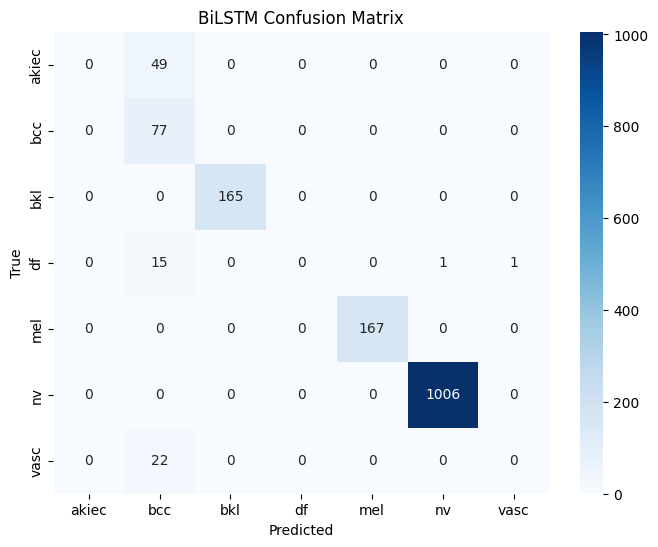

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "akiec","bcc","bkl","df","mel","nv","vasc"
    ],
    yticklabels=[
        "akiec","bcc","bkl","df","mel","nv","vasc"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BiLSTM Confusion Matrix")
plt.show()

# **Accuracy Curve**

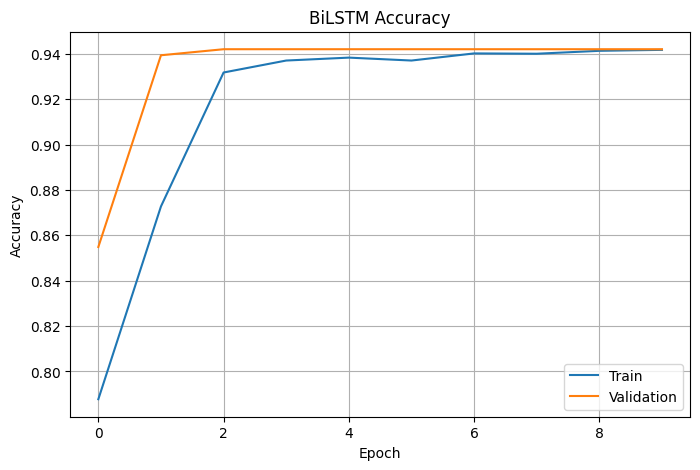

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# **Loss Curve**

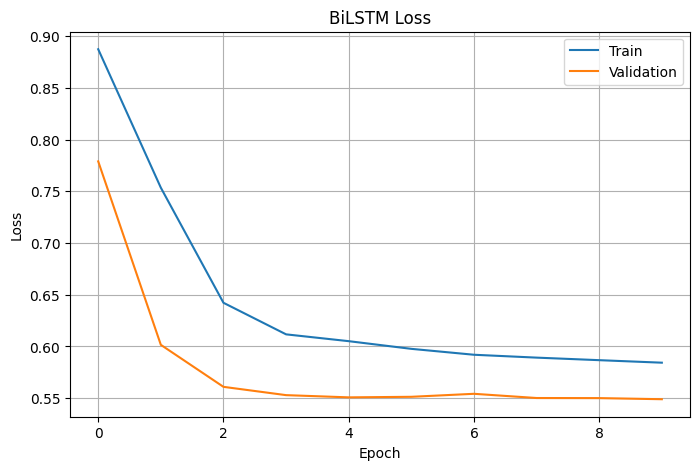

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# **Save padded sequences**

In [31]:
import pickle
import os

SAVE_DIR = "/content/drive/MyDrive/AI-TeleTriage-System/saved_objects"

os.makedirs(SAVE_DIR, exist_ok=True)

pickle.dump(X_train_pad, open(os.path.join(SAVE_DIR,"X_train_pad.pkl"),"wb"))
pickle.dump(X_val_pad,   open(os.path.join(SAVE_DIR,"X_val_pad.pkl"),"wb"))
pickle.dump(X_test_pad,  open(os.path.join(SAVE_DIR,"X_test_pad.pkl"),"wb"))

print("Text sequences saved.")

Text sequences saved.


# **Save labels**

In [32]:
pickle.dump(y_train, open(os.path.join(SAVE_DIR,"y_train.pkl"),"wb"))
pickle.dump(y_val,   open(os.path.join(SAVE_DIR,"y_val.pkl"),"wb"))
pickle.dump(y_test,  open(os.path.join(SAVE_DIR,"y_test.pkl"),"wb"))

print("Labels saved.")

Labels saved.


# **Save tokenizer**

In [33]:
pickle.dump(tokenizer,
            open(os.path.join(SAVE_DIR,"tokenizer.pkl"),"wb"))

print("Tokenizer saved.")

Tokenizer saved.


# **Verify**

In [34]:
print(os.listdir(SAVE_DIR))

['class_weights.pkl', 'custom_cnn_history.pkl', 'densenet_history.pkl', 'max_len.pkl', 'lstm_history.pkl', 'label_encoder.pkl', 'fusion_history.pkl', 'fusion_class_names.pkl', 'val_df.pkl', 'test_df.pkl', 'train_df.pkl', 'tokenizer.pkl', 'X_train_pad.npy', 'X_val_pad.npy', 'X_test_pad.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'bilstm_history.pkl', 'X_train_pad.pkl', 'X_val_pad.pkl', 'X_test_pad.pkl', 'y_train.pkl', 'y_val.pkl', 'y_test.pkl']


In [35]:
import os

MODEL_DIR = "/content/drive/MyDrive/AI-TeleTriage-System/models"

print(os.listdir(MODEL_DIR))

['custom_cnn_best.keras', 'custom_cnn_final.keras', 'densenet121_best.keras', 'lstm_best_final.keras', 'fusion_best.keras', 'lstm_best.keras', 'bilstm_best.keras']


# **Save Model**

In [36]:
model.save(
    "/content/drive/MyDrive/AI-TeleTriage-System/models/bilstm_best.keras"
)